
# Практическая работа №4: Элементы корреляционного анализа. Проверка статистической гипотезы о равенстве коэффициента корреляции нулю

Выполнили студенты гр. 2381 Комосский Егор Артемович и Рыжиков Иван Сергеевич. Вариант №17.


## Цель работы

Освоение основных понятий, связанных с корреляционной зависимостью между случайными величинами, статистическими гипотезами и проверкой их «справедливости».


## Основные теоретические положения

**Корреляционная зависимость** показывает наличие статистической связи между двумя случайными величинами $X$ и $Y$.

**Выборочный коэффициент корреляции** оценивает тесноту линейной связи и вычисляется по формуле

$$
r_{в}=\frac{\sum\limits_{i=1}^{k_x}\sum\limits_{j=1}^{k_y} n_{ij}(x_i-\bar{x}_{в})(y_j-\bar{y}_{в})}{N\,\sigma_x\sigma_y}.
$$

Здесь $n_{ij}$ — частота попадания в ячейку корреляционной таблицы, $x_i$ и $y_j$ — середины интервалов, $N$ — объем выборки.

Для вычислений с помощью **условных вариант** вводят

$$
u_i =
\frac{x_i-C_x}{h_x}, \qquad v_j = \frac{y_j-C_y}{h_y},
$$

где $C_x, C_y$ — условные начала отсчета, $h_x, h_y$ — длины интервалов. Тогда

$$
r_{в}=
\frac{m_{11}-m_{10}m_{01}}
{\sqrt{m_{20}-m_{10}^2}\sqrt{m_{02}-m_{01}^2}}.
$$

**Доверительный интервал** для коэффициента корреляции строят с помощью преобразования Фишера:

$$
z=\frac{1}{2}\ln\frac{1+r_{в}}{1-r_{в}},
\qquad
z \pm u_{\gamma}\frac{1}{\sqrt{N-3}}.
$$

После этого выполняют обратное преобразование:

$$
r = 	th(z).
$$

Для проверки гипотезы

$$
H_0:
r = 0, \qquad H_1:
r ≠ 0
$$

используют статистику

$$
t_{набл}=\frac{r_{в}\sqrt{N-2}}{\sqrt{1-r_{в}^2}}.
$$

Если $|t_{набл}| > t_{кр}$, то нулевая гипотеза отвергается.



## Постановка задачи

Из заданной генеральной совокупности сформировать выборку по второму признаку. Провести статистическую обработку второй выборки в объёме практических работ №1 и №2, с целью определения точечных статистических оценок параметров распределения исследуемого признака (математического ожидания, дисперсии, среднеквадратичного отклонения, асимметрии, эксцесса и коэффициента вариации). Для системы двух случайных величин $X$(первый признак) и $Y$(второй признак) сформировать двумерную выборку и найти статистическую оценку коэффициента корреляции, построить доверительный интервал для коэффициента корреляции и осуществить проверку статистической гипотезы о равенстве коэффициента корреляции нулю. Полученные результаты содержательно проинтерпретировать.



## Порядок выполнения работы

1. Провести статистическую обработку второй выборки в объёме практических работ №1 и №2, с целью определения точечных статистических оценок параметров распределения исследуемого признака (математического ожидания, дисперсии, среднеквадратичного отклонения, асимметрии, эксцесса, моды, медианы и коэффициента вариации). Оформить результаты в виде таблицы, сделать выводы.
2. Построить двумерный интервальный вариационный ряд, оформить в виде таблицы.
3. По полученному двумерному интервальному вариационному ряду построить корреляционную таблицу, сделать выводы.
4. Исходя из результатов корреляционной таблицы вычислить значение выборочного коэффициента корреляции двумя способами: с помощью стандартной формулы и с помощью условных вариант. Убедиться, что результаты совпадают. Сделать выводы.
5. Построить доверительный интервал для коэффициента корреляции при уровне значимости $\gamma \in \{0.95, 0.99\}$, сделать выводы.
6. Осуществить проверку статистической гипотезы о равенстве коэффициента корреляции нулю при заданном уровне значимости $\alpha = 0.05$, сделать выводы.


### Задача 1

Провести статистическую обработку второй выборки в объёме практических работ №1 и №2, с целью определения точечных статистических оценок параметров распределения исследуемого признака (математического ожидания, дисперсии, среднеквадратичного отклонения, асимметрии, эксцесса, моды, медианы и коэффициента вариации). Оформить результаты в виде таблицы, сделать выводы.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math



df = pd.read_csv(r"./abalone_sample.csv")
df.head()


,Height,Viscera_weight
0,0.160,0.3015
1,0.150,0.2150
2,0.195,0.2245
3,0.170,0.2665
4,0.145,0.1080


In [ ]:
# Проверка данных
df.info(), df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Height          108 non-null    float64
 1   Viscera_weight  108 non-null    float64
dtypes: float64(2)
memory usage: 1.8 KB


(None,
            Height  Viscera_weight
 count  108.000000      108.000000
 mean     0.139306        0.184361
 std      0.036611        0.113494
 min      0.030000        0.002000
 25%      0.120000        0.107250
 50%      0.145000        0.163500
 75%      0.170000        0.260125
 max      0.215000        0.564000)

In [ ]:
# Выбираем признак X = Viscera_weight
x = df["Viscera_weight"].to_numpy()
n = len(x)

# 4) Ранжированный ряд
x_sorted = np.sort(x)
x_sorted[:20], x_sorted[-10:], n


(array([0.002 , 0.0035, 0.008 , 0.0125, 0.028 , 0.0305, 0.0325, 0.0345,
        0.036 , 0.037 , 0.0405, 0.041 , 0.045 , 0.0465, 0.0545, 0.068 ,
        0.072 , 0.0735, 0.082 , 0.0835]),
 array([0.322 , 0.347 , 0.3755, 0.389 , 0.3925, 0.4065, 0.4195, 0.4515,
        0.526 , 0.564 ]),
 108)

In [ ]:
# 4) Вариационный ряд (уникальные значения и частоты)
vals, counts = np.unique(x_sorted, return_counts=True)

var_df = pd.DataFrame({
    "x": vals,
    "m": counts
})
var_df["m_tilde"] = var_df["m"] / n
var_df["m_cum"] = var_df["m"].cumsum()
var_df["m_tilde_cum"] = var_df["m_tilde"].cumsum()

var_df.head(10)


,x,m,m_tilde,m_cum,m_tilde_cum
0,0.0020,1,0.009259,1,0.009259
1,0.0035,1,0.009259,2,0.018519
2,0.0080,1,0.009259,3,0.027778
3,0.0125,1,0.009259,4,0.037037
4,0.0280,1,0.009259,5,0.046296
5,0.0305,1,0.009259,6,0.055556
6,0.0325,1,0.009259,7,0.064815
7,0.0345,1,0.009259,8,0.074074
8,0.0360,1,0.009259,9,0.083333
9,0.0370,1,0.009259,10,0.092593


In [ ]:
# 4) Интервальный ряд (по Стерджессу)
k = math.ceil(1 + 3.322 * math.log10(n))
xmin, xmax = float(x.min()), float(x.max())
h = (xmax - xmin) / k

# Границы интервалов
bins = np.array([xmin + i*h for i in range(k)] + [xmax])
# Чтобы максимум попал в последний интервал, делаем последнюю границу чуть больше xmax
bins[-1] = xmax + 1e-12

cats = pd.cut(x, bins=bins, right=False, include_lowest=True)
m = cats.value_counts().sort_index().to_numpy()

mid = (bins[:-1] + bins[1:]) / 2

int_df = pd.DataFrame({
    "i": np.arange(1, k+1),
    "[x_i; x_{i+1})": [f"[{bins[i]:.4f}; {bins[i+1]:.4f})" for i in range(k)],
    "x_tilde_i": np.round(mid, 6),
    "m_i": m,
})
int_df["m_tilde_i"] = int_df["m_i"] / n
int_df["m_i_cum"] = int_df["m_i"].cumsum()
int_df["m_tilde_i_cum"] = int_df["m_tilde_i"].cumsum()

int_df

,i,[x_i; x_{i+1}),x_tilde_i,m_i,m_tilde_i,m_i_cum,m_tilde_i_cum
0,1,[0.0020; 0.0722),0.037125,17,0.157407,17,0.157407
1,2,[0.0722; 0.1425),0.107375,28,0.259259,45,0.416667
2,3,[0.1425; 0.2127),0.177625,21,0.194444,66,0.611111
3,4,[0.2127; 0.2830),0.247875,23,0.212963,89,0.824074
4,5,[0.2830; 0.3532),0.318125,11,0.101852,100,0.925926
5,6,[0.3532; 0.4235),0.388375,5,0.046296,105,0.972222
6,7,[0.4235; 0.4937),0.458625,1,0.009259,106,0.981481
7,8,[0.4937; 0.5640),0.528875,2,0.018519,108,1.000000


In [ ]:
int_df

,i,[x_i; x_{i+1}),x_tilde_i,m_i,m_tilde_i,m_i_cum,m_tilde_i_cum
0,1,[0.0020; 0.0722),0.037125,17,0.157407,17,0.157407
1,2,[0.0722; 0.1425),0.107375,28,0.259259,45,0.416667
2,3,[0.1425; 0.2127),0.177625,21,0.194444,66,0.611111
3,4,[0.2127; 0.2830),0.247875,23,0.212963,89,0.824074
4,5,[0.2830; 0.3532),0.318125,11,0.101852,100,0.925926
5,6,[0.3532; 0.4235),0.388375,5,0.046296,105,0.972222
6,7,[0.4235; 0.4937),0.458625,1,0.009259,106,0.981481
7,8,[0.4937; 0.5640),0.528875,2,0.018519,108,1.000000


In [ ]:
import pandas as pd

# 1) Основная таблица с нужными названиями столбцов
df_int_pretty = int_df.rename(columns={
    "i": "i",
    "[x_i; x_{i+1})": "[x_i, x_{i+1})",
    "x_tilde_i": "x̃_i",
    "m_i": "m_i",
    "m_tilde_i": "m̃_i",
    "m_i_cum": "m_i^нак",
    "m_tilde_i_cum": "m̃_i^нак"
}).copy()


# 5) Строка "Σ"
row_sum = pd.DataFrame([{
    "i": "Σ",
    "[x_i, x_{i+1})": "",
    "x̃_i": "",
    "m_i": int_df["m_i"].sum(),
    "m̃_i": int_df["m_tilde_i"].sum(),
    "m_i^нак": "-",
    "m̃_i^нак": "-"
}])

result_int_df = pd.concat([df_int_pretty, row_sum], ignore_index=True)

result_int_df

,i,"[x_i, x_{i+1})",x̃_i,m_i,m̃_i,m_i^нак,m̃_i^нак
0,1,[0.0020; 0.0722),0.037125,17,0.157407,17,0.157407
1,2,[0.0722; 0.1425),0.107375,28,0.259259,45,0.416667
2,3,[0.1425; 0.2127),0.177625,21,0.194444,66,0.611111
3,4,[0.2127; 0.2830),0.247875,23,0.212963,89,0.824074
4,5,[0.2830; 0.3532),0.318125,11,0.101852,100,0.925926
5,6,[0.3532; 0.4235),0.388375,5,0.046296,105,0.972222
6,7,[0.4235; 0.4937),0.458625,1,0.009259,106,0.981481
7,8,[0.4937; 0.5640),0.528875,2,0.018519,108,1.0
8,Σ,,,108,1.000000,-,-


In [ ]:
k, h, xmin, xmax

(8, 0.07024999999999999, 0.002, 0.564)

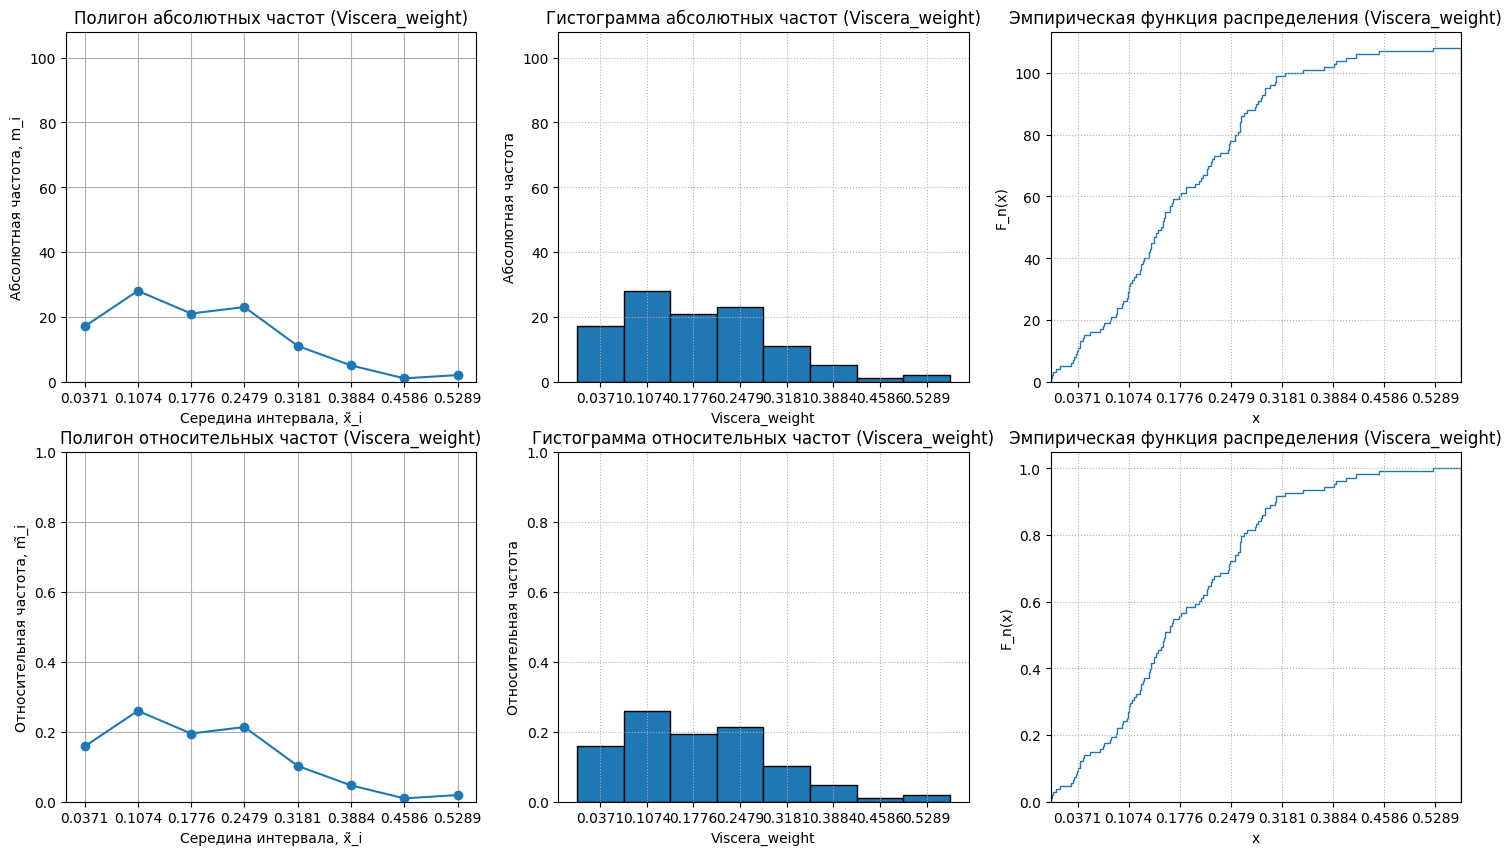

In [ ]:
# 5) Графики для абсолютных частот
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Полигон абсолютных частот

axs[0, 0].plot(int_df["x_tilde_i"], int_df["m_i"], marker="o")
axs[0, 0].set_xticks(int_df["x_tilde_i"])
axs[0, 0].set_xlabel("Середина интервала, x̃_i")
axs[0, 0].set_ylabel("Абсолютная частота, m_i")
axs[0, 0].set_ylim(0, n)
axs[0, 0].set_title("Полигон абсолютных частот (Viscera_weight)")
axs[0, 0].grid(True)


# Гистограмма абсолютных частот

axs[0, 1].hist(x, bins=bins, edgecolor="black")
axs[0, 1].set_xticks(int_df["x_tilde_i"])
# axs[0, 1].set_yticks(int_df["m_i"])
axs[0, 1].set_xlabel("Viscera_weight")
axs[0, 1].set_ylim(0, n)
axs[0, 1].set_ylabel("Абсолютная частота")
axs[0, 1].set_title("Гистограмма абсолютных частот (Viscera_weight)")
axs[0, 1].grid(ls='dotted')


# Эмпирическая функция распределения (ступенчатая)
df_ecdf = df["Viscera_weight"].value_counts().sort_index()
y_ecdf = df_ecdf.cumsum().to_numpy()
x_ecdf = [0] + df_ecdf.index.to_numpy().tolist()


axs[0, 2].stairs(y_ecdf, x_ecdf)
axs[0, 2].set_xlim(0, xmax)
axs[0, 2].set_xticks(int_df["x_tilde_i"])
axs[0, 2].set_xlabel("x")
axs[0, 2].set_ylabel("F_n(x)")
axs[0, 2].set_title("Эмпирическая функция распределения (Viscera_weight)")
axs[0, 2].grid(ls='dotted')


# 6) Графики для относительных частот

# Полигон относительных частот

axs[1, 0].plot(int_df["x_tilde_i"], int_df["m_tilde_i"], marker="o")
axs[1, 0].set_xticks(int_df["x_tilde_i"])
axs[1, 0].set_xlabel("Середина интервала, x̃_i")
axs[1, 0].set_ylabel("Относительная частота, m̃_i")
axs[1, 0].set_ylim(0, 1)
axs[1, 0].set_title("Полигон относительных частот (Viscera_weight)")
axs[1, 0].grid(True)


# Гистограмма относительных частот (высота = доля наблюдений в интервале)
# matplotlib.hist с weights строит именно доли (если weights=1/n)

axs[1, 1].hist(x, bins=bins, weights=np.ones_like(x)/n, edgecolor="black")
axs[1, 1].set_xticks(int_df["x_tilde_i"])
# axs[1, 1].set_yticks(int_df["m_tilde_i"])
axs[1, 1].set_ylim(0, 1)
axs[1, 1].set_xlabel("Viscera_weight")
axs[1, 1].set_ylabel("Относительная частота")
axs[1, 1].set_title("Гистограмма относительных частот (Viscera_weight)")
axs[1, 1].grid(ls='dotted')


# Эмперическая функция распределения (ступенчатая) от 0 до 1
df_ecdf = df["Viscera_weight"].value_counts().sort_index()
y_ecdf = df_ecdf.cumsum().to_numpy() / n
x_ecdf = [0] + df_ecdf.index.to_numpy().tolist()

axs[1, 2].stairs(y_ecdf, x_ecdf)
axs[1, 2].set_xlim(0, xmax)
axs[1, 2].set_xticks(int_df["x_tilde_i"])
axs[1, 2].set_xlabel("x")
axs[1, 2].set_ylabel("F_n(x)")
axs[1, 2].set_title("Эмпирическая функция распределения (Viscera_weight)")
axs[1, 2].grid(ls='dotted')

plt.show()



In [ ]:
a = bins[0:-1]    # нижние границы
b = bins[1:]   # верхние границы
n_i = int_df["m_i"]                                           # частоты
N = int(n_i.sum())
N, a, b, n_i

(108,
 array([0.002  , 0.07225, 0.1425 , 0.21275, 0.283  , 0.35325, 0.4235 ,
        0.49375]),
 array([0.07225, 0.1425 , 0.21275, 0.283  , 0.35325, 0.4235 , 0.49375,
        0.564  ]),
 0    17
 1    28
 2    21
 3    23
 4    11
 5     5
 6     1
 7     2
 Name: m_i, dtype: int64)

In [ ]:

# Середины интервалов
x_i = (a + b) / 2

# Шаг (ширина интервала)
h = float((b - a)[0])

# Условное начало отсчёта A: по умолчанию возьмём середину интервала с максимальной частотой
idx_modal = int(np.argmax(n_i))
C = float(x_i[idx_modal])

u_i = (x_i - C) / h

pd.DataFrame({
    "i": np.arange(1, len(x_i)+1),
    "a": a, "b": b,
    "x_i": x_i,
    "n_i": n_i,
    "u_i": u_i
})


,i,a,b,x_i,n_i,u_i
0,1,0.00200,0.07225,0.037125,17,-1.0
1,2,0.07225,0.14250,0.107375,28,0.0
2,3,0.14250,0.21275,0.177625,21,1.0
3,4,0.21275,0.28300,0.247875,23,2.0
4,5,0.28300,0.35325,0.318125,11,3.0
5,6,0.35325,0.42350,0.388375,5,4.0
6,7,0.42350,0.49375,0.458625,1,5.0
7,8,0.49375,0.56400,0.528875,2,6.0


In [ ]:

t1 = pd.DataFrame({
    "i": np.arange(1, len(x_i)+1),
    "x_i": x_i,
    "n_i": n_i,
    "u_i": u_i,
})

t1["n_i*u_i"]   = t1["n_i"] * t1["u_i"]
t1["n_i*u_i^2"] = t1["n_i"] * (t1["u_i"]**2)
t1["n_i*u_i^3"] = t1["n_i"] * (t1["u_i"]**3)
t1["n_i*u_i^4"] = t1["n_i"] * (t1["u_i"]**4)
t1["n_i*(u_i+1)^4"] = t1["n_i"] * ((t1["u_i"] + 1)**4)

# Суммы
sum_row = t1[["n_i", "n_i*u_i", "n_i*u_i^2", "n_i*u_i^3", "n_i*u_i^4", "n_i*(u_i+1)^4"]].sum()
sum_row.name = "Σ"

t1_display = t1.copy()
t1_display.loc["Σ", "i"] = None
t1_display.loc["Σ", "x_i"] = None
t1_display.loc["Σ", "n_i"] = sum_row["n_i"]
t1_display.loc["Σ", "u_i"] = None
t1_display.loc["Σ", "n_i*u_i"] = sum_row["n_i*u_i"]
t1_display.loc["Σ", "n_i*u_i^2"] = sum_row["n_i*u_i^2"]
t1_display.loc["Σ", "n_i*u_i^3"] = sum_row["n_i*u_i^3"]
t1_display.loc["Σ", "n_i*u_i^4"] = sum_row["n_i*u_i^4"]
t1_display.loc["Σ", "n_i*(u_i+1)^4"] = sum_row["n_i*(u_i+1)^4"]

t1_display


,i,x_i,n_i,u_i,n_i*u_i,n_i*u_i^2,n_i*u_i^3,n_i*u_i^4,n_i*(u_i+1)^4
0,1.0,0.037125,17.0,-1.0,-17.0,17.0,-17.0,17.0,4.132471e-62
1,2.0,0.107375,28.0,0.0,0.0,0.0,0.0,0.0,2.800000e+01
2,3.0,0.177625,21.0,1.0,21.0,21.0,21.0,21.0,3.360000e+02
3,4.0,0.247875,23.0,2.0,46.0,92.0,184.0,368.0,1.863000e+03
4,5.0,0.318125,11.0,3.0,33.0,99.0,297.0,891.0,2.816000e+03
5,6.0,0.388375,5.0,4.0,20.0,80.0,320.0,1280.0,3.125000e+03
6,7.0,0.458625,1.0,5.0,5.0,25.0,125.0,625.0,1.296000e+03
7,8.0,0.528875,2.0,6.0,12.0,72.0,432.0,2592.0,4.802000e+03
Σ,NaN,NaN,108.0,NaN,120.0,406.0,1362.0,5794.0,1.426600e+04


In [ ]:
control_sum = sum_row["n_i*u_i^4"] + 4 * sum_row["n_i*u_i^3"] + 6 * sum_row["n_i*u_i^2"] + 4 * sum_row["n_i*u_i"] + N

control_sum

np.float64(14266.00000001953)

In [ ]:

S1 = sum_row["n_i*u_i"]
S2 = sum_row["n_i*u_i^2"]
S3 = sum_row["n_i*u_i^3"]
S4 = sum_row["n_i*u_i^4"]

M1 = S1 / N
M2 = S2 / N
M3 = S3 / N
M4 = S4 / N

m2 = (M2 - M1**2)*h**2
m3 = (M3 - 3*M2*M1 + 2*(M1**3))*h**3
m4 = (M4 - 4*M3*M1 + 6*M2*(M1**2) - 3*(M1**4))*h**4

t2 = pd.DataFrame({
    "k": [1,2,3,4],
    "M*_k": [M1,M2,M3,M4],
    "m_k": [0, m2, m3, m4],
})
t2


,k,M*_k,m_k
0,1,1.111111,0.000000
1,2,3.759259,0.012460
2,3,12.611111,0.000979
3,4,53.648148,0.000508


In [ ]:
x_bar = sum(x_i*n_i)/N
x_bar_prime = C + h * M1

D = sum((x_i - x_bar) ** 2 * n_i ) / N
D_prime = m2
sigma = math.sqrt(m2)

S2_corr = (N/(N-1)) * D_prime if N > 1 else float("nan")
S_corr = math.sqrt(S2_corr) if N > 1 else float("nan")

As = m3 / (S_corr**3) if S_corr > 0 else float("nan")
Ex = (m4 / (S_corr**4) - 3) if S_corr > 0 else float("nan")




In [ ]:
# Вычисление моды
m_tilde = n_i / N

i = int(np.argmax(m_tilde))

# Нижняя граница модального интервала x_{i-1}
x_im1 = float(a[i])

mt_i   = float(m_tilde[i])
mt_im1 = float(m_tilde[i - 1]) if i > 0 else 0.0
mt_ip1 = float(m_tilde[i + 1]) if i < len(m_tilde) - 1 else 0.0

Mo = x_im1 + h * ((mt_i - mt_im1) / ((mt_i - mt_im1) + (mt_i - mt_ip1)))

# Вычисление медианы

m_tilde_cum = np.cumsum(m_tilde) # Накопленные относительные частоты
i = int(np.searchsorted(m_tilde_cum, 0.5, side="left"))
x_im1 = float(a[i])

# Сумма до предыдущего интервала
mt_i = float(m_tilde[i])
sum_prev = float(m_tilde_cum[i - 1]) if i > 0 else 0.0

Me = x_im1 + (h / mt_i) * (0.5 - sum_prev)

# Вычисление коэффициента вариации ---
V = (sigma / x_bar) * 100

pd.DataFrame({
    "Показатель": ["N", "C", "h", "x̄", "x̄'", "D", "D'",  "σ", "S² (испр.)", "S (испр.)", "A_s", "E_x", "M_o", "M_e", "V"],
    "Значение":   [N, C, h, x_bar, x_bar_prime, D, D_prime, sigma, S2_corr, S_corr, As, Ex, Mo, Me, V]
})


,Показатель,Значение
0,N,108.000000
1,C,0.107375
2,h,0.070250
3,x̄,0.185431
4,x̄',0.185431
5,D,0.012460
6,D',0.012460
7,σ,0.111622
8,S² (испр.),0.012576
9,S (испр.),0.112143


In [ ]:
# Границы интервала, где находится мода
a[i], a[i+1]

(np.float64(0.1425), np.float64(0.21275))

1. Самый частый интервал: `[0.0722; 0.1425)` с абсолютной частотой `28`, то есть `25.93%` от общего числа наблюдений.
2. Минимальное значение выборки: `0.002`.
3. Максимальное значение выборки: `0.564`.

На основе полигона, гистограммы и эмпирической функции распределения можно сделать следующие выводы.

1. Распределение данных:
   Основная часть наблюдений сосредоточена в интервалах от `0.0722` до `0.2830`. Наибольшая частота наблюдается в интервале `[0.0722; 0.1425)`. После интервала `[0.2127; 0.2830)` частоты заметно уменьшаются. Это указывает на наличие правого хвоста распределения.

2. Эмпирическая функция распределения:
   Эмпирическая функция распределения возрастает быстрее всего на первых четырех интервалах, где сосредоточена основная масса значений. Уже к границе `0.2830` накопленная относительная частота составляет `0.824074`, то есть около `82.4%` всех наблюдений. Далее функция растет медленнее, что подтверждает малое число больших значений.

3. Минимальное и максимальное значения:
   Минимальное значение выборки равно `0.002`, максимальное равно `0.564`.

Выборочные среднее `x̄` и дисперсия `D`, вычисленные по обычной формуле и методом условных вариант, совпали: `x̄ = 0.185431`, `D = 0.012460`. Это подтверждает правильность расчётов.

Исправленная дисперсия `S² = 0.012576` и исправленное среднее квадратическое отклонение `S = 0.112143` немного больше смещённых оценок `D = 0.012460` и `σ = 0.111622`, так как при исправлении деление идёт на `N − 1`, а не на `N`. При `N = 108` это расхождение небольшое.

Коэффициент асимметрии `A_s = 0.694146` положительный. Это говорит об умеренной правосторонней асимметрии распределения.

Эксцесс `E_x = 0.214261` положительный, но небольшой. Значит, распределение немного более остроконечное по сравнению с нормальным.

Соотношение `M_o = 0.115181`, `M_e = 0.172607` и `x̄ = 0.185431` имеет вид `M_o < M_e < x̄`. Это также подтверждает правостороннюю асимметрию.

Коэффициент вариации `V = 60.20%` показывает высокий относительный разброс. Значит, вариативность признака велика, и совокупность нельзя считать однородной.

## Задача 2

Построим двумерный интервальный вариационный ряд для признаков $X$ и $Y$.

In [ ]:

# Границы интервалов и двумерный интервальный вариационный ряд
bins_x = k
bins_y = k

X = df["Height"]
Y = df["Viscera_weight"]

freq, x_edges, y_edges = np.histogram2d(X, Y, bins=[bins_x, bins_y])
freq = freq.astype(int)

x_mid = (x_edges[:-1] + x_edges[1:]) / 2
y_mid = (y_edges[:-1] + y_edges[1:]) / 2

x_labels = [f'[{x_edges[i]:.3f}; {x_edges[i+1]:.3f})' for i in range(len(x_edges)-1)]
y_labels = [f'[{y_edges[j]:.3f}; {y_edges[j+1]:.3f})' for j in range(len(y_edges)-1)]

variation_table = pd.DataFrame(freq, index=x_labels, columns=y_labels)
variation_table.index.name = 'Интервалы X'
variation_table.columns.name = 'Интервалы Y'
variation_table


Интервалы Y,[0.002; 0.072),[0.072; 0.142),[0.142; 0.213),[0.213; 0.283),[0.283; 0.353),[0.353; 0.423),[0.423; 0.494),[0.494; 0.564)
Интервалы X,,,,,,,,
[0.030; 0.053),2,0,0,0,0,0,0,0
[0.053; 0.076),2,0,0,0,0,0,0,0
[0.076; 0.099),13,3,0,0,0,0,0,0
[0.099; 0.122),0,10,1,1,0,0,0,0
[0.122; 0.146),0,13,10,6,0,0,0,0
[0.146; 0.169),0,1,7,6,5,0,0,0
[0.169; 0.192),0,1,2,9,3,4,1,1
[0.192; 0.215),0,0,1,1,3,1,0,1


Полученная таблица показывает, сколько наблюдений попало в каждую пару интервалов. По диагональному скоплению частот уже видно положительную связь между признаками.

## Задача 3

Построим корреляционную таблицу. Для этого добавим итоги по строкам и столбцам.

In [ ]:

correlation_table = variation_table.copy()
correlation_table['Σ n_{i•}'] = correlation_table.sum(axis=1)

sum_row = correlation_table.sum(axis=0)
sum_row.name = 'Σ n_{•j}'
correlation_table = pd.concat([correlation_table, sum_row.to_frame().T])
correlation_table


Интервалы Y,[0.002; 0.072),[0.072; 0.142),[0.142; 0.213),[0.213; 0.283),[0.283; 0.353),[0.353; 0.423),[0.423; 0.494),[0.494; 0.564),Σ n_{i•}
[0.030; 0.053),2,0,0,0,0,0,0,0,2
[0.053; 0.076),2,0,0,0,0,0,0,0,2
[0.076; 0.099),13,3,0,0,0,0,0,0,16
[0.099; 0.122),0,10,1,1,0,0,0,0,12
[0.122; 0.146),0,13,10,6,0,0,0,0,29
[0.146; 0.169),0,1,7,6,5,0,0,0,19
[0.169; 0.192),0,1,2,9,3,4,1,1,21
[0.192; 0.215),0,0,1,1,3,1,0,1,7
Σ n_{•j},17,28,21,23,11,5,1,2,108


По корреляционной таблице видна положительная связь между признаками: с ростом X значения Y тоже в целом увеличиваются, так как основная масса частот сосредоточена вдоль восходящей диагонали. Связь не идеальная, но заметная, поскольку есть и отклонения от диагонального расположения.


## Задача 4

Вычислим выборочный коэффициент корреляции двумя способами: по стандартной формуле и с помощью условных вариант.

In [ ]:

# Способ 1. Стандартная формула по корреляционной таблице
row_totals = freq.sum(axis=1)
col_totals = freq.sum(axis=0)

x_bar_group = (x_mid * row_totals).sum() / N
y_bar_group = (y_mid * col_totals).sum() / N

sigma_x_group = math.sqrt((((x_mid - x_bar_group) ** 2) * row_totals).sum() / N)
sigma_y_group = math.sqrt((((y_mid - y_bar_group) ** 2) * col_totals).sum() / N)

numerator = 0.0
for i, xi in enumerate(x_mid):
    for j, yj in enumerate(y_mid):
        numerator += freq[i, j] * (xi - x_bar_group) * (yj - y_bar_group)

r_standard = numerator / (N * sigma_x_group * sigma_y_group)

# Способ 2. Условные варианты
h_x = x_edges[1] - x_edges[0]
h_y = y_edges[1] - y_edges[0]
C_x = x_mid[len(x_mid) // 2]
C_y = y_mid[len(y_mid) // 2]

u = (x_mid - C_x) / h_x
v = (y_mid - C_y) / h_y

m10 = (u * row_totals).sum() / N
m01 = (v * col_totals).sum() / N
m20 = ((u ** 2) * row_totals).sum() / N
m02 = ((v ** 2) * col_totals).sum() / N

m11 = 0.0
for i, ui in enumerate(u):
    for j, vj in enumerate(v):
        m11 += freq[i, j] * ui * vj
m11 /= N

r_conditional = (m11 - m10 * m01) / math.sqrt((m20 - m10**2) * (m02 - m01**2))

r_raw = np.corrcoef(X, Y)[0, 1]

r_table = pd.DataFrame({
    'Способ': ['Стандартная формула', 'Условные варианты', 'По исходным незгруппированным данным'],
    'Значение коэффициента корреляции': [r_standard, r_conditional, r_raw]
})
r_table


,Способ,Значение коэффициента корреляции
0,Стандартная формула,0.795243
1,Условные варианты,0.795243
2,По исходным незгруппированным данным,0.820864


Коэффициент корреляции положительный и высокий: `r ≈ 0.80`, значит между признаками существует сильная прямая связь. Совпадение результатов по стандартной формуле и методу условных вариант подтверждает правильность расчётов, а немного большее значение по незгруппированным данным объясняется тем, что группировка всегда даёт небольшую потерю точности.


## Задача 5

Построим доверительные интервалы для коэффициента корреляции при $\gamma \in \{0.95, 0.99\}$ с помощью преобразования Фишера.

In [ ]:
from scipy import stats

gammas = [0.95, 0.99]
z = 0.5 * np.log((1 + r_standard) / (1 - r_standard))
ci_rows = []

for gamma in gammas:
    u_gamma = stats.norm.ppf((1 + gamma) / 2)
    delta = u_gamma / math.sqrt(N - 3)
    z_left = z - delta
    z_right = z + delta
    r_left = np.tanh(z_left)
    r_right = np.tanh(z_right)
    ci_rows.append([gamma, u_gamma, r_left, r_right])

ci_table = pd.DataFrame(ci_rows, columns=['γ', 'u_γ', 'Левая граница', 'Правая граница'])
ci_table


,γ,u_γ,Левая граница,Правая граница
0,0.95,1.959964,0.713493,0.855632
1,0.99,2.575829,0.682704,0.870928


С вероятностью 0.95 истинный коэффициент корреляции находится в интервале от `0.713` до `0.856`, а с вероятностью 0.99 от `0.683` до `0.871`. Оба интервала содержат только положительные и достаточно большие значения, значит между признаками сохраняется устойчивая сильная прямая связь.


## Задача 6

Проверим гипотезу $H_0:
r = 0$ при уровне значимости $\alpha = 0.05$. Используем двусторонний критерий Стьюдента.

In [ ]:
k

8

In [ ]:

alpha = 0.05
df = k - 2

t_obs = r_standard * math.sqrt(df / (1 - r_standard ** 2))
t_crit = stats.t.ppf(1 - alpha / 2, df=df)

hypothesis_table = pd.DataFrame({
    'Показатель': ['r_в', 't_набл', 't_кр', 'α'],
    'Значение': [r_standard, t_obs, t_crit, alpha]
})
hypothesis_table


,Показатель,Значение
0,r_в,0.795243
1,t_набл,3.212882
2,t_кр,2.446912
3,α,0.050000


Так как `t_набл = 3.213 > t_кр = 2.447`, нулевая гипотеза о равенстве коэффициента корреляции нулю отвергается. Значит, между признаками существует статистически значимая линейная связь.



## Выводы

В ходе работы была выполнена статистическая обработка второй выборки, найдены основные числовые характеристики распределения и построен двумерный интервальный вариационный ряд.

1. Вторая выборка имеет умеренную правостороннюю асимметрию: основная часть наблюдений сосредоточена в интервалах от 0.0722 до 0.2830, а самый частый интервал это [0.0722; 0.1425). Коэффициент вариации 60.2% показывает высокий разброс, поэтому совокупность по `Viscera_weight` неоднородна.

2. Построен двумерный интервальный вариационный ряд и на его основе составлена корреляционная таблица.

3. По корреляционной таблице установлено наличие заметной прямой зависимости между признаками X и Y. Выборочный коэффициент корреляции оказался высоким (`r ≈ 0.80`), а его значения, полученные разными способами, практически совпали, что подтверждает корректность расчётов.

5. Доверительные интервалы для коэффициента корреляции при $\gamma = 0.95$ и $\gamma = 0.99$ не содержат нуль. Что говорит о том, что истинный коэффициент корреляции с высокой вероятностью остаётся положительным и достаточно большим.


6. Проверка гипотезы `H₀: r = 0` при уровне значимости `α = 0.05` привела к её отклонению, следовательно, между исследуемыми признаками существует статистически значимая линейная связь.
